# MRR2 Spectral Processing

## IMProToo

This section will overview processing raw MRR2 data with IMProToo.

### References
Maahn, M. and Kollias, P.: Improved Micro Rain Radar snow measurements using Doppler spectra post-processing, Atmos. Meas. Tech. Discuss., 5, 4771-4808, doi:10.5194/amtd-5-4771-2012, 2012. http://www.atmos-meas-tech-discuss.net/5/4771/2012/amtd-5-4771-2012.html

In [22]:
import IMProToo
import xarray as xr
import matplotlib.pyplot as plt

First, load the raw data.

In [3]:
improtoo_ds = IMProToo.mrrRawData("../data/0520.raw")

1 of 1: ../data/0520.raw


Then, we process the spectra from the raw data.

In [4]:
processed_spec = IMProToo.MrrZe(improtoo_ds)

Here, we have to add the following information:
   * Averaging interval (this is typically 60 s for the MRR2)
   * A field showing who created the file (ncCreator)
   * A field describing the data (ncDescription)
   * A flag to enable the dealiasing of Doppler spectrum (dealiaseSpectrum)

In [5]:
processed_spec.averageSpectra(60)
processed_spec.co["ncCreator"] = "Robert Jackson, Argonne National Laboratory"
processed_spec.co["ncDescription"] = "MRR data from CROCUS Urban Canyons"
processed_spec.co["dealiaseSpectrum"] = True
# We then process the outputs
processed_spec.rawToSnow()
# Write the outputs to a netCDF file
processed_spec.writeNetCDF("0520.improtoo.nc")

/Users/rjackson/miniforge3/envs/crocus_env/lib/python3.13/site-packages/IMProToo/core.py:1493: RuntimeWarning: invalid value encountered in sqrt
  specWidth = np.sqrt(mom2).filled(-9999)
/Users/rjackson/miniforge3/envs/crocus_env/lib/python3.13/site-packages/IMProToo/core.py:1514: RuntimeWarning: invalid value encountered in log10
  peakEtaLeftBorder = 10*np.log10(etaSpectraFlat[list(range(
/Users/rjackson/miniforge3/envs/crocus_env/lib/python3.13/site-packages/IMProToo/core.py:1516: RuntimeWarning: divide by zero encountered in log10
  peakEtaRightBorder = 10*np.log10(etaSpectraFlat[list(range(
/Users/rjackson/miniforge3/envs/crocus_env/lib/python3.13/site-packages/IMProToo/core.py:1516: RuntimeWarning: invalid value encountered in log10
  peakEtaRightBorder = 10*np.log10(etaSpectraFlat[list(range(
/Users/rjackson/miniforge3/envs/crocus_env/lib/python3.13/site-packages/IMProToo/core.py:1519: RuntimeWarning: invalid value encountered in log10
  peakEtaMax = 10*np.log10(np.max(eta.fille

The resulting netCDF file can be open using xarray.

In [9]:
improtoo_spec = xr.open_dataset("0520.improtoo.nc")
improtoo_spec = improtoo_spec.set_coords(["time", "height"])

Let's plot some spectra!

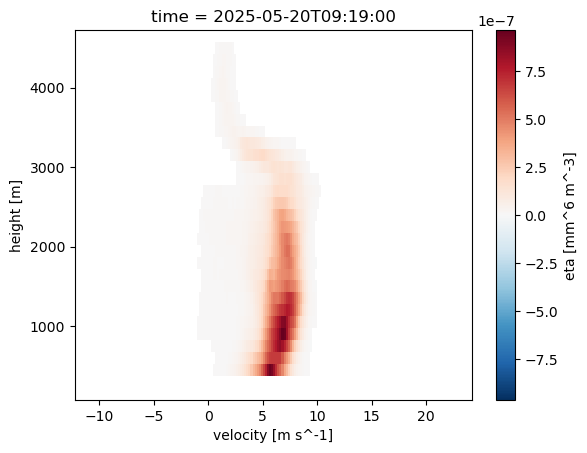

In [23]:
improtoo_spec["eta"].where(improtoo_spec["etaMask"] == 0).sel(
    time="2025-05-20T09:19:00", method='nearest').plot(y='height')

## RaProM

First, we need to do the proper imports. The original repo for RaProM is available at (https://github.com/AlbertGBena/RaProM). This notebook contains a refactored version of RaProM that allows for easy calling of RaProM from within a Jupyter Notebook and includes updates to the package to be compatible to Python 3.14 and xarray.

### References
Garcia-Benadi A, Bech J, Gonzalez S, Udina M, Codina B, Georgis J-F. Precipitation Type Classification of Micro Rain Radar Data Using an Improved Doppler Spectral Processing Methodology. Remote Sens. 2020, 12, 4113. https://doi.org/10.3390/rs12244113

In [34]:
import raprom

In [36]:
out = raprom.process_file('../data/0520.raw')

File in process  /Users/rjackson/MRR-Processing-Intercomparison/data/0520
2026-06-05 17:22:47.655748
2026-06-05 17:23:45.285516




In [15]:
ds = xr.open_dataset(out)
ds

<xarray.Dataset> Size: 15MB
Dimensions:                              (time: 1440, Height: 31,
                                          PIA_Height: 32, DropSize: 64,
                                          BB_Height: 1, Dm_ax: 33, Nw_ax: 94)
Coordinates:
  * time                                 (time) datetime64[ns] 12kB 2025-05-2...
  * Height                               (Height) float32 124B 150.0 ... 4.65...
  * PIA_Height                           (PIA_Height) float32 128B 0.0 ... 4....
  * DropSize                             (DropSize) float32 256B nan ... nan
  * BB_Height                            (BB_Height) float32 4B 9.969e+36
  * Dm_ax                                (Dm_ax) float32 132B 0.2 0.3 ... 3.4
  * Nw_ax                                (Nw_ax) float32 376B -2.0 -1.9 ... 7.3
Data variables: (12/22)
    W                                    (time, Height) float32 179kB ...
    spectral width                       (time, Height) float32 179kB ...
    Skewness                             (time, Height) float32 179kB ...
    Kurtosis                             (time, Height) float32 179kB ...
    PIA                                  (time, PIA_Height) float32 184kB ...
    PIA_all                              (time, PIA_Height) float32 184kB ...
    ...                                   ...
    Noise                                (time, Height) float32 179kB ...
    Nw                                   (time, Height) float32 179kB ...
    Dm                                   (time, Height) float32 179kB ...
    BB_bottom                            (time, BB_Height) float32 6kB ...
    BB_top                               (time, BB_Height) float32 6kB ...
    TyPrecipi                            (Dm_ax, Nw_ax) float32 12kB ...
Attributes:
    description:  Data processed by MRR radar
    author:       Albert Garcia Benadí
    orcid:        0000-0002-5560-4392

## Loading the Metek processed files

The Metek .pro files can be opened using [xradar](https://docs.openradarscience.org/projects/xradar/en/stable/), an open source data framework for weather radar data. The below import line adds an engine to xarray that supports loading metek .pro files for analysis using xarray-based syntax.

In [17]:
import xradar as xd

In [19]:
ds_metek = xr.open_dataset('../data/0520.pro', engine='metek')

In [20]:
ds_metek

<xarray.Dataset> Size: 430MB
Dimensions:                      (sample: 64, time: 8660, range: 31,
                                  index: 268455)
Coordinates:
  * time                         (time) datetime64[ns] 69kB 2025-05-20T00:00:...
  * range                        (range) float64 248B 150.0 300.0 ... 4.65e+03
    velocity_bins                (sample) float64 512B ...
Dimensions without coordinates: sample, index
Data variables: (12/17)
    transfer_function            (time, range) float64 2MB ...
    spectral_reflectivity        (index, sample) float64 137MB ...
    drop_size                    (index, sample) float64 137MB ...
    drop_number_density          (index, sample) float64 137MB ...
    percentage_valid_spectra     (time) float64 69kB ...
    path_integrated_attenuation  (time, range) float64 2MB ...
    ...                           ...
    altitude                     float64 8B ...
    longitude                    float64 8B ...
    latitude                     float64 8B ...
    spectrum_index               (time, range) float64 2MB ...
    azimuth                      (time) float64 69kB ...
    elevation                    (time) float64 69kB ...

## Side-by-side comparison

Let's plot the reflectivity side by side.

In [ ]:
fig, ax = plt.subplots(3, 1, figsize=(10, 7), sharex=True)
start_time = '2025-05-20T08:00:00'
end_time = '2025-05-20T13:00:00'
improtoo_spec['Ze'].sel(time=slice(start_time, end_time)).T.plot(
    cmap='Spectral_r', vmin=-10, vmax=50, y='height', ax=ax[0],
    cbar_kwargs={'label': 'Ze [dBZ]'})
ds['Ze'].sel(time=slice(start_time, end_time)).T.plot(
    cmap='Spectral_r', vmin=-10, vmax=50, ax=ax[1],
    cbar_kwargs={'label': 'Ze [dBZ]'})
ds_metek['corrected_reflectivity'].sel(time=slice(start_time, end_time)).T.plot(
    cmap='Spectral_r', vmin=-10, vmax=50, ax=ax[2],
    cbar_kwargs={'label': 'Ze [dBZ]'})
ax[0].set_xlabel('')
ax[1].set_xlabel('')
ax[2].set_xlabel("Time")
ax[0].set_title("IMProToo")
ax[1].set_title("RaProM")
ax[2].set_title("Factory processing")

There are significant differences in the reflectivity fields shown. In particular, the RaProM-generated reflectivities are biased low compared to both the factory processed and the IMProToo-generated fields. Qualitatively, the bright band is most apparent in the RaProM-processed data. In addition, the data above the brightband from both ImProToo and RaProM are less noisy, showing the capability of these alternate processing methods to better process weak echoes that are characteristic of snowfall.

For rainfall, it is worth comparing the retrieved rainfall rates from the different processing methodologies against the $Parsivel^{2}$ Therefore, in the next notebook, we will go over calibration of the MRR2.